# %% [markdown]
# `pipeline_hopfield_expandido` — Pipeline Completo com Dataset Expandido (~11.000 genes)

Reimplementação do fluxo de análise de tipo celular e memória associativa Hopfield no **dataset expandido**.

**Contexto biológico.** O experimento parte de matrizes binárias de expressão
gênica (~40 000 células Fujita × ~45 000 células Mathys). São selecionados os
**5 000 genes mais frequentes do Fujita acrescidos dos ~6 000 genes do Fujita ausentes no Mathys**
(preenchidos com valor 0.5 para o Mathys), totalizando aproximadamente **11.000 genes**.
Cada célula é representada por um vetor SWeeP de **600 dimensões** via projeção da matriz expandida
(rSWeeP, AIBIALab). A memória associativa armazena perfis **binários no espaço de ~11.000 genes**;
o espaço SWeeP é usado para clusterizar e escolher protótipos.

**Diferenças principais:**
- Espaço gênico expandido para ~11.000 genes.
- Remapeamento de classes seguindo o padrão do script01: classes não presentes
  em `[1, 3, 4, 5, 6, 7]` são remapeadas para a classe `2`.
- Configuração: `nc=30` clusters por classe, `k=1` representante por centroide
  → **210 padrões** (7 classes × 30 subclusters).

**Rede utilizada:** Modern Hopfield Network (Ramsauer et al., 2020) com
capacidade de armazenamento exponencial e recuperação equivalente a um passo
de *attention* (`softmax(β · Ξ · ξ) · Ξᵀ`).

## 1. Imports e configuração


In [1]:
import sys, os
import gc
import importlib
import numpy as np
import pandas as pd
import polars as pl
import torch
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, classification_report

SRC_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'src')
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import config
importlib.reload(config)
from config import (
    PATH_M, PATH_F, PATH_FEATURES_F, PATH_FEATURES_M,
    PATH_SWEEP_F, PATH_SWEEP_M, PATH_LABELS_F, PATH_LABELS_M,
    OUT_BINARIZACAO, OUT_ALINHAMENTO, OUT_TOP_GENES,
    OUT_TREINAMENTO, OUT_HOPFIELD, OUT_RELATORIO,
)

from preprocessing import Binarizador
from alinhamento import (
    LeitorFeatures, AnalisadorSobreposicao, Alinhador,
    ValidadorAlinhamento, SelecionadorGenesFrequentes, AnalisadorCobertura,
)
from treinamento import (
    GeradorConjuntoTreinamento, CarregadorDadosFujita,
    ProjetorSWeP, ProjetorSWeePR,
    ExtratorPadroesSubcluster, ModernHopfieldNetwork, AvaliadorHopfield,
    GeradorRelatorio,
)
from treinamento.hopfield_utils import wsort, closervects

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cpu')
print(f'Dispositivo: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    torch.cuda.manual_seed_all(SEED)


# 
# Converte as matrizes de expressão `.h5ad` para formato binário (valores > 0 → 1,
# zeros → 0). O `Binarizador` detecta automaticamente se o arquivo já existe e
# pula o processamento nesse caso.

Dispositivo: cpu


## 2. Binarização

Converte as matrizes de expressão `.h5ad` para formato binário (valores > 0 → 1, zeros → 0). O `Binarizador` detecta automaticamente se o arquivo já existe e pula o processamento nesse caso.


In [2]:
binarizador_f = Binarizador(path_h5ad=PATH_F, out_dir=OUT_BINARIZACAO)
binarizador_m = Binarizador(path_h5ad=PATH_M, out_dir=OUT_BINARIZACAO)

binarizador_f.binarizar()
binarizador_m.binarizar()

print('Fujita binarizado em:', binarizador_f.path_binarizada)
print('Mathys binarizado em:', binarizador_m.path_binarizada)


# 
# Os dois datasets têm espaços gênicos distintos (36 591 genes no Fujita,
# 32 643 no Mathys, ~30 312 em comum). O alinhamento:
# 
# 1. Lê os mapeamentos `gene_name → Ensembl ID` de cada dataset.
# 2. Define a ordem canônica dos genes baseada no Fujita (referência).
# 3. Realinha ambas as matrizes para esse espaço canônico.
#    - Genes ausentes no **Mathys** são preenchidos com `0.5` como sentinela.
# 4. Valida que as duas matrizes resultantes têm genes na mesma ordem.

[Binarizador] Arquivo já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\binarizacao\matrizFiltradaeNormalizadaF\matrizBinarizadaM.h5ad
[Binarizador] Arquivo já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\binarizacao\matrizFiltradaeNormalizadaMParcial\matrizBinarizadaM.h5ad
Fujita binarizado em: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\binarizacao\matrizFiltradaeNormalizadaF\matrizBinarizadaM.h5ad
Mathys binarizado em: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\binarizacao\matrizFiltradaeNormalizadaMParcial\matrizBinarizadaM.h5ad


## 3. Alinhamento de espaços gênicos

Os dois datasets têm espaços gênicos distintos (36 591 genes no Fujita, 32 643 no Mathys, ~30 312 em comum). O alinhamento:

1. Lê os mapeamentos `gene_name → Ensembl ID` de cada dataset.
2. Define a ordem canônica dos genes baseada no Fujita (referência).
3. Realinha ambas as matrizes para esse espaço canônico.
   - Genes ausentes no **Mathys** são preenchidos com `0.5` como sentinela.
4. Valida que as duas matrizes resultantes têm genes na mesma ordem.


In [3]:
# Passo 1 — Leitura dos arquivos de features
leitor = LeitorFeatures(PATH_FEATURES_F, PATH_FEATURES_M)
leitor.ler()
print(leitor)

[LeitorFeatures] Fujita : 36591 genes mapeados
[LeitorFeatures] Mathys : 32643 genes mapeados
LeitorFeatures(
  path_features_f = C:\Users\Leticia\Documents\Letworkspace\Sweep-Harmonization\Meus_testes\Controle_qualidade\dataF\dados_combinados\features.tsv\features.tsv
  path_features_m = C:\Users\Leticia\Documents\Letworkspace\Sweep-Harmonization\Meus_testes\Controle_qualidade\dataM\featuresM.tsv.gz
  map_f           = 36591 genes
  map_m           = 32643 genes
)


In [4]:
# Passo 2 — Análise de sobreposição dos espaços gênicos
# var_names idênticos no original e no binarizado — lemos direto do original
_f = ad.read_h5ad(PATH_F, backed='r')
var_names_f_original = _f.var_names.tolist()
_f.file.close()
del _f

analisador = AnalisadorSobreposicao(leitor.map_f, leitor.map_m, var_names_f_original)
analisador.analisar()
print(analisador)

[AnalisadorSobreposicao] Em comum  : 30312
[AnalisadorSobreposicao] Só Fujita : 6279
[AnalisadorSobreposicao] Só Mathys : 2331  ← serão excluídos
[AnalisadorSobreposicao] Espaço gênico final: 36601 genes
AnalisadorSobreposicao(
  ids_comuns      = 30312
  ids_so_f        = 6279
  ids_so_m        = 2331
  genes_ordenados = 36601
)


In [5]:
# Passo 3 — Alinhamento dos dois h5ad binarizados
alinhador = Alinhador(
    path_binarizada_m = binarizador_m.path_binarizada,
    path_binarizada_f = binarizador_f.path_binarizada,
    out_dir           = OUT_ALINHAMENTO,
    map_f             = leitor.map_f,
    map_m             = leitor.map_m,
    gene_alvo_idx     = analisador.gene_alvo_idx,
    genes_ordenados   = analisador.genes_ordenados,
)
alinhador.alinhar()
alinhador.salvar_como_txt()
alinhador.gerar_tracking(analisador.ids_so_f, leitor.map_f)
print(alinhador)

[Alinhador] Fujita já alinhado, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataF_binarizado_alinhado\adataF_binarizado_alinhado.h5ad
[Alinhador] Mathys já alinhado, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataM_binarizado_alinhado\adataM_binarizado_alinhado.h5ad

[Alinhador] Concluído.
[Alinhador] TXT já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataF_binarizado_alinhado\adataF_binarizado_alinhado.txt
[Alinhador] TXT já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataM_binarizado_alinhado\adataM_binarizado_alinhado.txt
[Alinhador] Tracking já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\tracking_genes_adicionados_mathys.csv
Alinhador(
  path_binarizada_m = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\binarizacao\ma

In [6]:
# Passo 4 — Validação da ordem de genes
validador = ValidadorAlinhamento(
    path_f_alinhado = alinhador.path_f_alinhado,
    path_m_alinhado = alinhador.path_m_alinhado,
    genes_ordenados = analisador.genes_ordenados,
)
validador.validar()


# 
# Puxa os 5.000 genes mais frequentes do Fujita E todos os genes nativos do Fujita
# que estavam ausentes no Mathys (rastreados no var.csv). Resulta em um espaço com
# dimensionalidade ampliada para recuperar falhas e deficiências naturais do Mathys.

[ValidadorAlinhamento] Carregando metadados...
✓ Número de genes idêntico: 36601
✓ Fujita alinhado == ordem de referência
✓ Mathys alinhado == ordem de referência
✓ Fujita alinhado == Mathys alinhado
[ValidadorAlinhamento] Validação concluída com sucesso.


ValidadorAlinhamento(
  path_f_alinhado  = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataF_binarizado_alinhado\adataF_binarizado_alinhado.h5ad
  path_m_alinhado  = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataM_binarizado_alinhado\adataM_binarizado_alinhado.h5ad
  genes_ordenados  = 36601 genes
)

## 4. Seleção Expandida (Top 5k Fujita + Genes Exclusivos do Fujita)

Puxa os 5.000 genes mais frequentes do Fujita E todos os genes nativos do Fujita que estavam ausentes no Mathys (rastreados no var.csv). Resulta em um espaço com dimensionalidade ampliada (~11.000 genes) para recuperar falhas e deficiências naturais do Mathys.


In [7]:
path_top_5000 = os.path.join(OUT_TOP_GENES, 'top_5000_frequentes.csv')
path_top_expandidos = os.path.join(OUT_TOP_GENES, 'genes_expandidos_frequentes.csv')
path_f_expandido = os.path.join(OUT_TREINAMENTO, 'adataF_binarizado_alinhado_expandido.npy')
path_m_expandido = os.path.join(OUT_TREINAMENTO, 'adataM_binarizado_alinhado_expandido.npy')

path_f_txt = alinhador.path_f_alinhado.replace('.h5ad', '.txt')
path_m_txt = alinhador.path_m_alinhado.replace('.h5ad', '.txt')

import polars as pl
print(f'=== Calculando Córtex Expandido (Top 5000 + Exclusivos do Fujita) ===')

selecionador = SelecionadorGenesFrequentes(path_f_txt, n=5000).calcular(path_top_5000)
top_5000_genes = selecionador.df_resultado['gene'].to_list()

tracking_path = os.path.join(OUT_ALINHAMENTO, 'tracking_genes_adicionados_mathys.csv')
df_tracking = pl.read_csv(tracking_path)
exclusivos_fujita = df_tracking.filter(pl.col('presente_mathys') == False)['ensembl_id'].to_list()

genes_unificados = list(set(top_5000_genes).union(set(exclusivos_fujita)))
print(f'  Genes Top 5.000 padrão: {len(top_5000_genes)}')
print(f'  Genes Exclusivos Faltantes catalogados no Mathys: {len(exclusivos_fujita)}')
print(f'  Dimensionalidade final unificada para a Hopfield: {len(genes_unificados)}\n')

selecionador.df_resultado = pl.DataFrame({'gene': genes_unificados})
selecionador.df_resultado.write_csv(path_top_expandidos)

selecionador.filtrar_matriz(path_f_txt, path_f_expandido)

print(f'\n[Mathys] Filtrando genes nas novas dimensões... (genes faltando aparecerão como 0.5 perfeitamente)')
selecionador.filtrar_matriz(path_m_txt, path_m_expandido)

print('\nVerificando cobertura no Mathys nas Dimensões Expandidas:')
cobertura = AnalisadorCobertura(path_top_expandidos, leitor.map_f, leitor.map_m)
cobertura.analisar(out_csv=os.path.join(OUT_TREINAMENTO, 'cobertura_mathys_expandida.csv'))



=== Calculando Córtex Expandido (Top 5000 + Exclusivos do Fujita) ===
[SelecionadorGenesFrequentes] Lendo: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\alinhamento\adataF_binarizado_alinhado\adataF_binarizado_alinhado.txt
  Calculando frequências para 36601 genes (streaming por chunks)...
  10000 células processadas...
  20000 células processadas...
  30000 células processadas...
  40000 células processadas...
  40913 células processadas...
[SelecionadorGenesFrequentes] Concluído. Top 5000 genes selecionados.
  Genes Top 5.000 padrão: 5000
  Genes Exclusivos Faltantes catalogados no Mathys: 6279
  Dimensionalidade final unificada para a Hopfield: 11185

[SelecionadorGenesFrequentes] Matriz filtrada salva em binário: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\adataF_binarizado_alinhado_expandido.npy ((40913, 11186))

[Mathys] Filtrando genes nas novas dimensões... (genes faltando aparecerão como 0.5 perfeitamente)
[SelecionadorGe

ensembl_id,presente_mathys,sem_ensembl_fujita
str,bool,bool
"""ENSG00000150907""",true,false
"""ENSG00000138709""",true,false
"""ENSG00000198663""",true,false
"""ENSG00000197586""",true,false
"""AC090515.6""",false,false
…,…,…
"""ENSG00000120925""",true,false
"""ENSG00000186566""",true,false
"""AC087439.2""",false,false


In [8]:
# Conjuntos de treinamento filtrados (Fujita + Mathys)
gerador = GeradorConjuntoTreinamento(
    path_top_genes_csv = path_top_expandidos,
    out_dir            = OUT_TREINAMENTO,
)
gerador.gerar(path_f_txt)
gerador.gerar(path_m_txt)
print(gerador)

[GeradorConjuntoTreinamento] 11185 genes carregados de: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\top_genes\genes_expandidos_frequentes.csv
[GeradorConjuntoTreinamento] Arquivo já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\adataF_binarizado_alinhado_top11185.txt
[GeradorConjuntoTreinamento] Arquivo já existe, pulando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\adataM_binarizado_alinhado_top11185.txt
GeradorConjuntoTreinamento(
  path_top_genes_csv = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\top_genes\genes_expandidos_frequentes.csv
  out_dir            = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento
  genes_selecionados = 11185
)


## 5. Projeção SWeeP (rSWeeP via R / fallback Python)

Projeta a matriz binarizada expandida do Fujita (~11.000 genes) no espaço SWeeP de 600 dimensões usando a base ortonormal rSWeeP.
Se o R não estiver disponível, `ProjetorSWeePR` usa o fallback Python (QR sintético).

```
Wswp = W0 @ R_expandido        (células × 600)
```


In [9]:
PATH_SWEEP_F_EXPANDIDO = os.path.join(OUT_TREINAMENTO, 'matriz_reduzida_sweepF_expandido.csv')

projetor_r = ProjetorSWeePR(
    path_matriz   = path_f_expandido,
    path_saida    = PATH_SWEEP_F_EXPANDIDO,
    n_componentes = 600,
    seed          = SEED,
)
projetor_r.projetar()

[ProjetorSWeePR] Arquivo já existe, carregando: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\matriz_reduzida_sweepF_expandido.csv
[ProjetorSWeePR] Wswp carregado: (40913, 600)


ProjetorSWeePR(
  path_matriz   = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\adataF_binarizado_alinhado_expandido.npy
  path_saida    = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\matriz_reduzida_sweepF_expandido.csv
  n_componentes = 600
  seed          = 42
  Wswp          = (40913, 600)
)

## 6. Carregamento dos dados

Carrega:
- `W0`: matriz binária Fujita expandida (células × ~11 000 genes) — usada como padrões da rede.
- `labels`: rótulos inteiros de tipo celular por célula.
- `Wswp`: projeções SWeeP da matriz expandida pré-computadas (células × 600) — usadas para K-means.


In [10]:
# Fujita — padrões de treinamento
carregador = CarregadorDadosFujita(
    path_matriz = path_f_expandido,
    path_genes  = path_top_expandidos,
    path_labels = PATH_LABELS_F,
    path_sweep  = PATH_SWEEP_F_EXPANDIDO,
    n_genes     = len(genes_unificados),
)
carregador.carregar()
print(carregador)



[CarregadorDadosFujita] Carregando matriz: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\adataF_binarizado_alinhado_expandido.npy
[CarregadorDadosFujita] Matriz carregada: (40913, 11186)
[CarregadorDadosFujita] W0 shape: (40913, 11186) (11186 genes)
[CarregadorDadosFujita] Carregando genes: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\top_genes\genes_expandidos_frequentes.csv
[CarregadorDadosFujita] 11185 genes carregados
[CarregadorDadosFujita] Carregando rótulos: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\imputs\cell_types_binarioF.txt
[CarregadorDadosFujita] Rótulos shape: (40913,), tipos: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
[CarregadorDadosFujita] Carregando SWeeP pré-computado: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\treinamento\matriz_reduzida_sweepF_expandido.csv
[CarregadorDadosFujita] Wswp shape: (40913, 600)
[CarregadorDadosFujita] Carregamento concluído: 4

In [11]:
# Mathys — dados para imputação cross-dataset
# Genes ausentes no Mathys foram preenchidos com 0.5 (sentinela) pelo Alinhador.
print(f'[Mathys] Carregando matriz expandida ({len(genes_unificados)} genes)...')
if str(path_m_expandido).endswith('.npy'):
    W_mathys = np.load(path_m_expandido).astype(np.float32, copy=False)
else:
    W_mathys = pl.read_csv(path_m_expandido).to_numpy().astype(np.float32)
print(f'[Mathys] W_mathys shape: {W_mathys.shape}')

print('[Mathys] Carregando rótulos...')
labels_mathys = np.loadtxt(PATH_LABELS_M, dtype=int, skiprows=1)
print(f'[Mathys] labels shape: {labels_mathys.shape}, tipos: {np.unique(labels_mathys)}')


# 
# Seguindo o padrão do `script01_analises_preliminares.m` original:
# classes não presentes em `[1, 3, 4, 5, 6, 7]` são remapeadas para `2`,
# resultando em 7 classes: Excitatory (1), Endothelial/remapeadas (2),
# Inhibitory (3), Astrocytes (4), Microglia (5), Oligodendrocytes (6),
# OPCs (7).
# 
# clo = cl;
# clo(~ismember(clo,[1 3 4 5 6 7 0])) = 2;

[Mathys] Carregando matriz expandida (11185 genes)...
[Mathys] W_mathys shape: (45663, 11186)
[Mathys] Carregando rótulos...
[Mathys] labels shape: (45663,), tipos: [1 2 3 4 5 6 7 8]


## 7. Remapeamento de classes (clo)

Seguindo o padrão do `script01_analises_preliminares.m` original:
classes não presentes em `[1, 3, 4, 5, 6, 7]` são remapeadas para `2`, resultando em 7 classes: Excitatory (1), Endothelial/remapeadas (2), Inhibitory (3), Astrocytes (4), Microglia (5), Oligodendrocytes (6), OPCs (7).

```matlab
clo = cl;
clo(~ismember(clo,[1 3 4 5 6 7 0])) = 2;
```


In [12]:
clo = carregador.labels.copy()
clo[~np.isin(clo, [1, 3, 4, 5, 6, 7, 0])] = 2

clo_m = labels_mathys.copy()
clo_m[~np.isin(clo_m, [1, 3, 4, 5, 6, 7, 0])] = 2

print('Distribuição Fujita (clo):')
vals, counts = np.unique(clo, return_counts=True)
for v, c in zip(vals, counts):
    print(f'  classe {v}: {c:>6d} células')

print('\nDistribuição Mathys (clo_m):')
vals_m, counts_m = np.unique(clo_m, return_counts=True)
for v, c in zip(vals_m, counts_m):
    print(f'  classe {v}: {c:>6d} células')


# 
# Aplica PCA **sem centralização** sobre as projeções SWeeP — equivalente ao
# `pca(W, 'Centered', false)` do MATLAB. Os scores resultantes `Wpc`
# são usados como espaço auxiliar para visualizações e análises.

Distribuição Fujita (clo):
  classe 0:  13905 células
  classe 1:   4366 células
  classe 2:    433 células
  classe 3:   9073 células
  classe 4:   4567 células
  classe 5:   1734 células
  classe 6:   5762 células
  classe 7:   1073 células

Distribuição Mathys (clo_m):
  classe 1:   2597 células
  classe 2:    159 células
  classe 3:  24548 células
  classe 4:   6420 células
  classe 5:    485 células
  classe 6:   9218 células
  classe 7:   2236 células


## 8. PCA no espaço SWeeP

Aplica PCA **sem centralização** sobre as projeções SWeeP — equivalente ao `pca(W, 'Centered', false)` do MATLAB. Os scores resultantes `Wpc` são usados como espaço auxiliar para visualizações e análises.


In [13]:
projetor = ProjetorSWeP(n_features=carregador.W0.shape[1], n_componentes=600, seed=SEED)

projetor.usar_sweep_precomputado(carregador.Wswp).aplicar_pca()
print(projetor)


# 
# Scatter plot dos dois primeiros componentes principais do espaço SWeeP do Fujita,
# colorido por tipo celular (`clo`). Permite verificar se os 7 tipos já formam grupos
# separados **antes** do treinamento da rede — separação visual aqui indica que o espaço
# SWeeP captura bem as diferenças biológicas entre os tipos celulares.
# 
# `projetor.Wpc` já está calculado na célula anterior; nenhum novo cálculo é necessário.

[ProjetorSWeP] SWeeP pré-computado definido: (40913, 600)
[ProjetorSWeP] Aplicando PCA sem centralização...
[ProjetorSWeP] Wpc shape: (40913, 600)
ProjetorSWeP(
  n_features    = 11186
  n_componentes = 600
  seed          = 42
  R             = não gerada
  Wswp          = (40913, 600)
  Wpc           = (40913, 600)
)


## 8b. Visualização PCA — separação das classes no espaço SWeeP

Scatter plot dos dois primeiros componentes principais do espaço SWeeP do Fujita, colorido por tipo celular (`clo`). Permite verificar se os 7 tipos já formam grupos separados **antes** do treinamento da rede — separação visual aqui indica que o espaço SWeeP captura bem as diferenças biológicas entre os tipos celulares.

`projetor.Wpc` já está calculado na célula anterior; nenhum novo cálculo é necessário.


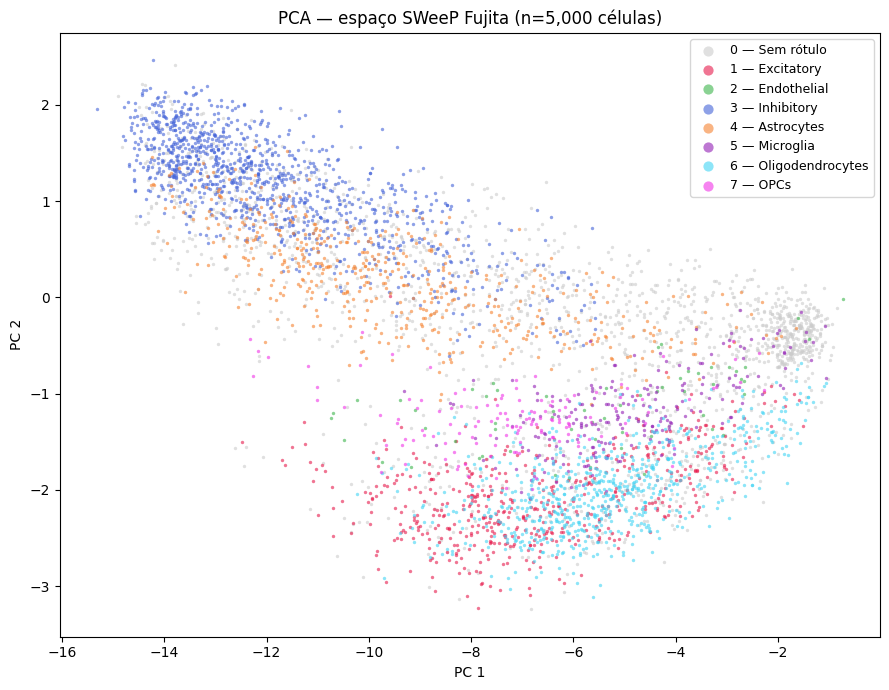

In [14]:
# PCA scatter — PC1 × PC2 colorido por tipo celular (amostra 5 000 células)
rng_pca = np.random.default_rng(SEED)
idx_pca = rng_pca.choice(len(projetor.Wpc), min(5000, len(projetor.Wpc)), replace=False)

CLASSE_NOMES = {0: 'Sem rótulo', 1: 'Excitatory', 2: 'Endothelial',
                3: 'Inhibitory',  4: 'Astrocytes', 5: 'Microglia',
                6: 'Oligodendrocytes', 7: 'OPCs'}
CORES = {0: '#cccccc', 1: '#e6194b', 2: '#3cb44b', 3: '#4363d8',
         4: '#f58231', 5: '#911eb4', 6: '#42d4f4', 7: '#f032e6'}

fig_pca, ax = plt.subplots(figsize=(9, 7))
for cls in sorted(CORES):
    mask = clo[idx_pca] == cls
    if mask.any():
        ax.scatter(projetor.Wpc[idx_pca][mask, 0],
                   projetor.Wpc[idx_pca][mask, 1],
                   c=CORES[cls], label=f'{cls} — {CLASSE_NOMES[cls]}',
                   s=6, alpha=0.6, linewidths=0)
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.set_title(f'PCA — espaço SWeeP Fujita (n={len(idx_pca):,} células)')
ax.legend(markerscale=3, fontsize=9, loc='best')
plt.tight_layout(); plt.show()


# 
# Para cada uma das 7 classes executa KMeans com `nc=30` clusters no espaço
# SWeeP e seleciona o vetor binário mais próximo de cada centroide como
# representante. Resulta em `7 × 30 = 210 padrões`.
# 
# for ii in classes:
#     km = kmeans(Wswp[clo==ii], nc)
#     for centroide in km.centroids:
#         idx = closervects(Wswp[clo==ii], centroide, k=1)
#         perf35.append(W0[clo==ii][idx])

## 9. Extração de padrões por subcluster (perf35)

Para cada uma das 7 classes executa KMeans com `nc=30` clusters no espaço SWeeP e seleciona o vetor binário mais próximo de cada centroide como representante no espaço expandido (~11.000 genes). Resulta em `7 × 30 = 210 padrões`.

```matlab
for ii in classes:
    km = kmeans(Wswp[clo==ii], nc)
    for centroide in km.centroids:
        idx = closervects(Wswp[clo==ii], centroide, k=1)
        perf35.append(W0[clo==ii][idx])
```


In [15]:
from treinamento.extrator_padroes import EstrategiaKMeansDinamico
estr_kmeans = EstrategiaKMeansDinamico(k_range=[30], seed=SEED)

extrator = ExtratorPadroesSubcluster(
    estrategia=estr_kmeans,
    W0      = carregador.W0,
    labels  = clo,
    classes = [1, 2, 3, 4, 5, 6, 7],
    seed    = SEED,
    k       = 1,
    nc      = 30,
)
extrator.extrair(projetor.Wswp)
perf35 = extrator.padroes
print(extrator)
print(f'perf35 shape: {perf35.shape}  (esperado: (210, ~11000))')

[ExtratorPadroesSubcluster] Classe 1: n=4366 Aplicando estratégia de clusterização...
[EstrategiaKMeansDinamico] Melhor k encontrado: 30 (Calinski-Harabasz: 18.90)
[ExtratorPadroesSubcluster] Classe 2: n=433 Aplicando estratégia de clusterização...
[EstrategiaKMeansDinamico] Melhor k encontrado: 30 (Calinski-Harabasz: 3.78)
[ExtratorPadroesSubcluster] Classe 3: n=9073 Aplicando estratégia de clusterização...
[EstrategiaKMeansDinamico] Melhor k encontrado: 30 (Calinski-Harabasz: 43.88)
[ExtratorPadroesSubcluster] Classe 4: n=4567 Aplicando estratégia de clusterização...
[EstrategiaKMeansDinamico] Melhor k encontrado: 30 (Calinski-Harabasz: 30.39)
[ExtratorPadroesSubcluster] Classe 5: n=1734 Aplicando estratégia de clusterização...
[EstrategiaKMeansDinamico] Melhor k encontrado: 30 (Calinski-Harabasz: 6.04)
[ExtratorPadroesSubcluster] Classe 6: n=5762 Aplicando estratégia de clusterização...
[EstrategiaKMeansDinamico] Melhor k encontrado: 30 (Calinski-Harabasz: 18.89)
[ExtratorPadroesSub

## 10. Treinamento da rede (rede35)

Armazena os 210 padrões do dataset expandido (~11.000 genes) na Modern Hopfield Network.

**Regra de armazenamento:** simplesmente guardar os padrões — não há treinamento iterativo.

**Parâmetros:**
- `beta=50.0`: temperatura inversa do softmax (maior → mais winner-takes-all)
- `n_iters=1`: uma iteração de atualização já é suficiente
- `threshold=0.8`: limiar para binarização da saída da rede

**Persistência:** O modelo (.pt) e seus metadados (.json) são salvos em `outputs/hopfield/` via `salvar_com_metadados`.


In [16]:
rede35 = ModernHopfieldNetwork(beta=50.0, n_iters=1, binary=True, threshold=0.8)
# Armazena os 210 padrões no espaço de ~11k genes
rede35.store(perf35)
meta_eval = extrator.meta  # mapeamento padrao -> classe

PATH_PT   = os.path.join(OUT_HOPFIELD, 'rede35_v2.pt')
PATH_META = os.path.join(OUT_HOPFIELD, 'rede35_v2_metadata.json')

# Salva pesos (.pt) e metadados (.json)
rede35.salvar_com_metadados(PATH_PT, PATH_META, meta=extrator.meta, classes=[1, 2, 3, 4, 5, 6, 7], nc=30)
print(rede35)

[ModernHopfieldNetwork] 210 padrões armazenados (11186 genes, device=cpu)
[ModernHopfieldNetwork] Rede salva em: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\hopfield\rede35_v2.pt (210 padrões)
[ModernHopfieldNetwork] Metadados salvos em: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\hopfield\rede35_v2_metadata.json (210 padrões, 11186 genes)
ModernHopfieldNetwork(
  beta       = 50.0
  n_iters    = 1
  binary     = True
  threshold  = 0.8
  patterns   = 210 × 11186
)


## 10b. Alternativa: carregar rede pré-treinada

**Use esta célula em vez das seções 9 e 10** quando o treinamento foi feito em outra máquina ou em execução anterior.
Carrega os arquivos `rede35_v2.pt` e `rede35_v2_metadata.json` salvos na pasta `outputs/hopfield/`.

Se treinou acima (seções 9 e 10), **pule esta célula**.


In [17]:
PATH_PT   = os.path.join(OUT_HOPFIELD, 'rede35_v2.pt')
PATH_META = os.path.join(OUT_HOPFIELD, 'rede35_v2_metadata.json')

# Carrega rede e metadados via método unificado
rede35, meta_eval, _meta_json = ModernHopfieldNetwork.carregar_com_metadados(PATH_PT, PATH_META)

# Reconstrói perf35 em {0,1} a partir dos padrões salvos em {-1,+1}
perf35 = ((rede35.patterns.cpu().numpy() + 1.0) / 2.0).clip(0.0, 1.0).astype('float32')

print(rede35)
print(f'perf35 shape: {perf35.shape}')
print(f'Classes: {_meta_json.get("classes")}  nc={_meta_json.get("nc")}  padroes={_meta_json.get("n_patterns")}')

[ModernHopfieldNetwork] Rede carregada de: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\hopfield\rede35_v2.pt (210 padrões)
[ModernHopfieldNetwork] Metadados carregados de: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\hopfield\rede35_v2_metadata.json (classes=[1, 2, 3, 4, 5, 6, 7], nc=30, n_patterns=210)
ModernHopfieldNetwork(
  beta       = 50.0
  n_iters    = 1
  binary     = True
  threshold  = 0.8
  patterns   = 210 × 11186
)
perf35 shape: (210, 11186)
Classes: [1, 2, 3, 4, 5, 6, 7]  nc=30  padroes=210


## 11. Teste numa subclasse (clo == 3)

Seguindo o padrão do `script01`: embaralha aleatoriamente as células da classe 3 e testa as primeiras 1 000 células (amostra representativa).

```matlab
Wk4  = wsort(W0(clo==3, :));          % embaralhamento aleatório
Wtes = hopf_ts(Wk4(1:1000,:), rede35);
```


In [18]:
NC = 30
CLASSES_ARR = np.array([1, 2, 3, 4, 5, 6, 7])

# Agora a query é o espaço W0 Binário Original no dataset expandido (~11k genes)
Wk4    = wsort(carregador.W0[clo == 3])
n_test = min(1000, Wk4.shape[0])
Wtes   = rede35.retrieve(Wk4[:n_test], batch_size=4096)
print(f'hopf_ts(Wk4[:{n_test}], rede35): shape {Wtes.shape}')


perf35_f = perf35.astype(np.float32, copy=False)
Wtes_f   = Wtes.astype(np.float32, copy=False)
a2 = (Wtes_f ** 2).sum(axis=1, keepdims=True)
b2 = (perf35_f ** 2).sum(axis=1, keepdims=True).T
idx_proto = (a2 + b2 - 2 * (Wtes_f @ perf35_f.T)).argmin(axis=1)
pred_sub  = CLASSES_ARR[idx_proto // NC]

acc_sub = (pred_sub == 3).mean()
print(f'\nAcurácia subclasse clo==3: {acc_sub * 100:.2f}%')

[ModernHopfieldNetwork] Recuperação concluída: torch.Size([1000, 11186])
hopf_ts(Wk4[:1000], rede35): shape (1000, 11186)

Acurácia subclasse clo==3: 96.50%


              precision    recall  f1-score   support

           2       0.00      0.00      0.00         0
           3       1.00      0.96      0.98      1000
           4       0.00      0.00      0.00         0

    accuracy                           0.96      1000
   macro avg       0.33      0.32      0.33      1000
weighted avg       1.00      0.96      0.98      1000



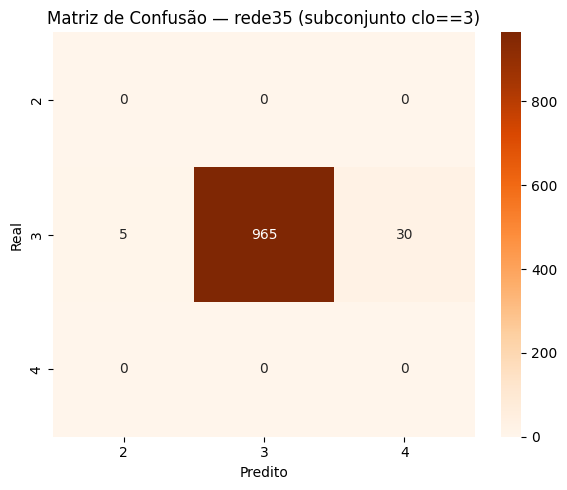

In [19]:
y_true_sub = np.full(n_test, 3)
labels_sub = sorted(set(y_true_sub) | set(pred_sub))
print(classification_report(y_true_sub, pred_sub, labels=labels_sub, zero_division=0))

cm_sub = confusion_matrix(y_true_sub, pred_sub, labels=labels_sub)
fig, ax = plt.subplots(figsize=(max(6, len(labels_sub)), max(5, len(labels_sub))))
sns.heatmap(cm_sub, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels_sub, yticklabels=labels_sub, ax=ax)
ax.set_xlabel('Predito'); ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — rede35 (subconjunto clo==3)')
plt.tight_layout(); plt.show()

## 12. Auto-imputação — Fujita → Fujita

Baseline interno: a rede treinada em Fujita recebe as próprias células Fujita.
Esperamos alta taxa de reconstrução e classificação.


=== Auto-imputação: Fujita → Fujita ===
[ModernHopfieldNetwork] Recuperação concluída: torch.Size([40913, 11186])
[AvaliadorHopfield] Mapeando padrões recuperados para classes (processamento em lotes em float32)...
[AvaliadorHopfield] Acurácia: 95.10% (n=27,008)
[AvaliadorHopfield] F1 macro=0.8896, F1 ponderado=0.9547
[AvaliadorHopfield] Taxa de reconstrução exata : 98.61%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9994
              precision    recall  f1-score   support

           1       1.00      0.95      0.97      4366
           2       0.37      0.74      0.49       433
           3       0.98      0.97      0.97      9073
           4       0.94      0.89      0.91      4567
           5       0.96      0.96      0.96      1734
           6       0.97      0.99      0.98      5762
           7       0.97      0.91      0.94      1073

    accuracy                           0.95     27008
   macro avg       0.88      0.92      0.89     27008
weighted avg       0.96 

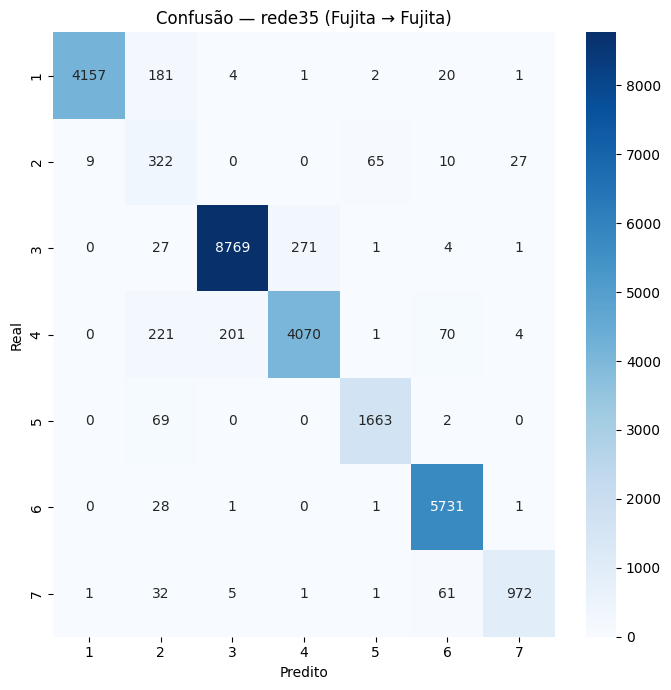

AvaliadorHopfield(
  padroes            = (210, 11186)
  classes            = [1, 2, 3, 4, 5, 6, 7]
  nc                 = 30
  acuracia           = 95.10%
  f1_macro           = 0.8896
  f1_weighted        = 0.9547
  taxa_reconstrucao  = 98.61%
  semelhanca_media   = 0.9994
)


16179

In [21]:
import gc

print('=== Auto-imputação: Fujita → Fujita ===')
Wrecuperado_f = rede35.retrieve(carregador.W0, batch_size=2048)

avaliador_f = AvaliadorHopfield(
    padroes = perf35,
    classes = [1, 2, 3, 4, 5, 6, 7],
    nc=30,
    meta    = meta_eval,
)
avaliador_f.avaliar(Wrecuperado_f, clo).plotar(titulo='Confusão — rede35 (Fujita → Fujita)')
print(avaliador_f)

del Wrecuperado_f
gc.collect()

## 13. Imputação cross-dataset — Mathys com sentinela 0.5

A rede treinada em Fujita recebe células do Mathys. Os 6 289 genes ausentes no Mathys foram preenchidos com `0.5` pelo `Alinhador` — o limiar `threshold=0.8` da rede os trata adequadamente na binarização da query antes da recuperação.


=== Imputação cross-dataset: Mathys ===

--- Processo de Imputação ---
Usando template Fujita para preencher buracos do Mathys (np.where(== 0.5))
[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 11186])
Genes faltantes originais Mathys (0.5): 286717977
Genes faltantes após Imputação: 0
Matriz Mathys Imputada Exportada para: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\top_genes\X_mathys_IMPUTADO_rede35.npy
[AvaliadorHopfield] Mapeando padrões recuperados para classes (processamento em lotes em float32)...
[AvaliadorHopfield] Acurácia: 26.61% (n=45,663)
[AvaliadorHopfield] F1 macro=0.1218, F1 ponderado=0.2926
[AvaliadorHopfield] Taxa de reconstrução exata : 97.29%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9992
              precision    recall  f1-score   support

           1       0.04      0.02      0.03      2597
           2       0.00      0.04      0.00       159
           3       0.55      0.33      0.41     24548
           4  

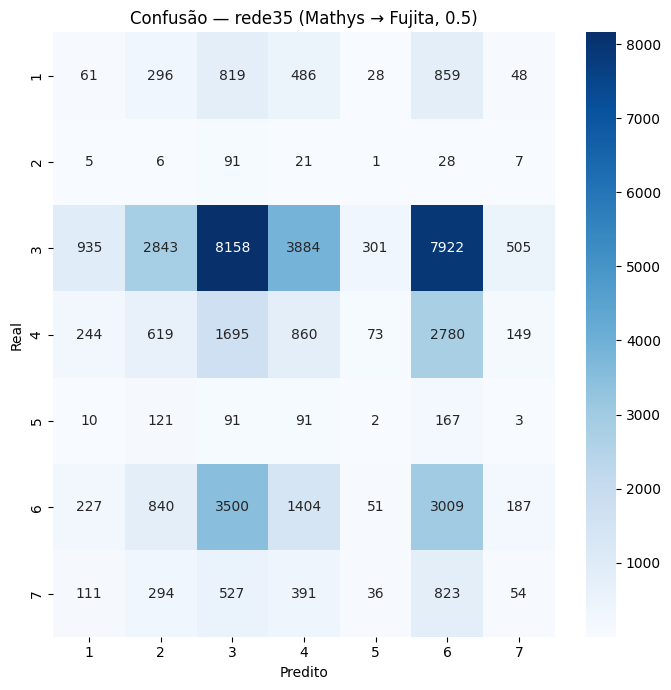

AvaliadorHopfield(
  padroes            = (210, 11186)
  classes            = [1, 2, 3, 4, 5, 6, 7]
  nc                 = 30
  acuracia           = 26.61%
  f1_macro           = 0.1218
  f1_weighted        = 0.2926
  taxa_reconstrucao  = 97.29%
  semelhanca_media   = 0.9992
)


8020

In [22]:
import gc

print('=== Imputação cross-dataset: Mathys ===')

print('\n--- Processo de Imputação ---')
print('Usando template Fujita para preencher buracos do Mathys (np.where(== 0.5))')

Wrecuperado_m = rede35.retrieve(W_mathys, batch_size=1024)

mask_sentinela = (W_mathys == 0.5)
genes_faltantes_qtd = int(mask_sentinela.sum())

mask_nao_sentinela = ~mask_sentinela
diff_frac = float((W_mathys[mask_nao_sentinela] != Wrecuperado_m[mask_nao_sentinela]).mean())

W_mathys_imputado = np.where(mask_sentinela, Wrecuperado_m, W_mathys)
genes_resolvidos_qtd = int((W_mathys_imputado == 0.5).sum())

print(f'Genes faltantes originais Mathys (0.5): {genes_faltantes_qtd}')
print(f'Genes faltantes após Imputação: {genes_resolvidos_qtd}')

# Guarda contagem de ativações para visualização na Seção 17
recuperados_count = np.sum(W_mathys_imputado != 0.5, axis=0)

os.makedirs(OUT_TOP_GENES, exist_ok=True)
PATH_IMPUTADO = os.path.join(OUT_TOP_GENES, 'X_mathys_IMPUTADO_rede35.npy')
np.save(PATH_IMPUTADO, W_mathys_imputado)
print(f'Matriz Mathys Imputada Exportada para: {PATH_IMPUTADO}')

del W_mathys_imputado
gc.collect()

avaliador_m = AvaliadorHopfield(
    padroes = perf35,
    classes = [1, 2, 3, 4, 5, 6, 7],
    nc=30,
    meta    = meta_eval,
)
avaliador_m.avaliar(Wrecuperado_m, clo_m).plotar(titulo='Confusão — rede35 (Modelo Fujita → Mathys, Sentinela 0.5)')
print(avaliador_m)

# Liberar Wrecuperado_m para economizar 2GB de RAM antes da Seção 14
del Wrecuperado_m
gc.collect()

## 14. Imputação cross-dataset — Mathys binário puro (0.5 → 0)

Comparação: converte os valores sentinela `0.5 → 0` antes da recuperação, equivalente a tratar todos os genes ausentes como definitivamente inativos. Permite comparar o impacto do sentinela `0.5` na qualidade da recuperação.


Valores convertidos de 0.5 → 0: 286717977
Valores únicos após conversão: [0. 1.]

=== Imputação cross-dataset: Mathys (binário puro, sem 0.5) ===
[ModernHopfieldNetwork] Recuperação concluída: torch.Size([45663, 11186])
[AvaliadorHopfield] Mapeando padrões recuperados para classes (processamento em lotes em float32)...
[AvaliadorHopfield] Acurácia: 23.97% (n=45,663)
[AvaliadorHopfield] F1 macro=0.1136, F1 ponderado=0.2750
[AvaliadorHopfield] Taxa de reconstrução exata : 97.50%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9992
              precision    recall  f1-score   support

           1       0.03      0.02      0.02      2597
           2       0.00      0.06      0.00       159
           3       0.55      0.30      0.39     24548
           4       0.12      0.14      0.13      6420
           5       0.00      0.00      0.00       485
           6       0.20      0.29      0.23      9218
           7       0.05      0.01      0.02      2236

    accuracy              

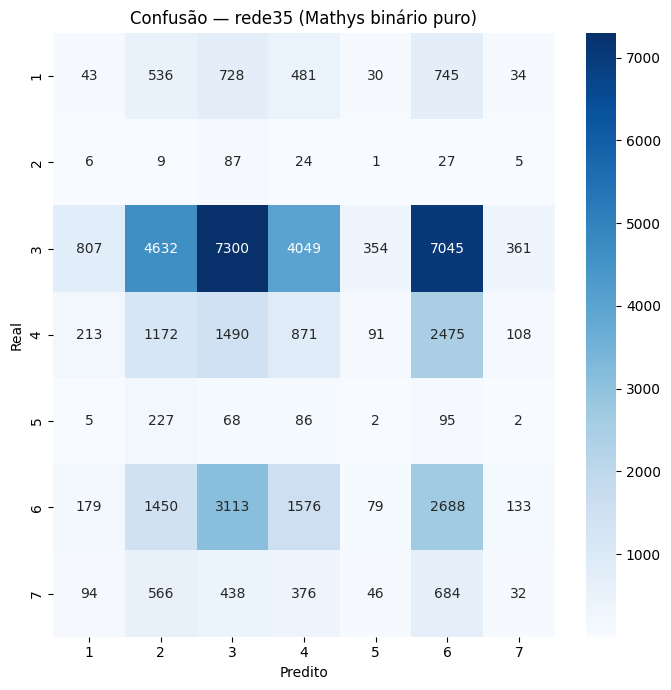

AvaliadorHopfield(
  padroes            = (210, 11186)
  classes            = [1, 2, 3, 4, 5, 6, 7]
  nc                 = 30
  acuracia           = 23.97%
  f1_macro           = 0.1136
  f1_weighted        = 0.2750
  taxa_reconstrucao  = 97.50%
  semelhanca_media   = 0.9992
)


7918

In [23]:
import gc

mask_sentinela = (W_mathys == 0.5)
n_meio = int(mask_sentinela.sum())

W_mathys_bin = np.where(mask_sentinela, 0.0, W_mathys)
print(f'Valores convertidos de 0.5 → 0: {n_meio}')
print(f'Valores únicos após conversão: {np.unique(W_mathys_bin)}')

print('\n=== Imputação cross-dataset: Mathys (binário puro, sem 0.5) ===')
Wrecuperado_m_bin = rede35.retrieve(W_mathys_bin, batch_size=1024)

del W_mathys_bin
gc.collect()

avaliador_m_bin = AvaliadorHopfield(
    padroes = perf35,
    classes = [1, 2, 3, 4, 5, 6, 7],
    nc=30,
    meta    = meta_eval,
)
avaliador_m_bin.avaliar(Wrecuperado_m_bin, clo_m).plotar(titulo='Confusão — rede35 (Modelo Fujita → Mathys, Binário Puro)')
print(avaliador_m_bin)

del Wrecuperado_m_bin
gc.collect()

## 15. Diagnóstico: mapeamento de classes Mathys → protótipos Fujita


In [24]:
print("=== Diagnóstico: distribuição de protótipos selecionados por classe Mathys ===\n")

# Reutiliza os protótipos mais próximos já calculados em lotes pelo avaliador_m
idx_proto_m = avaliador_m.idx_proto
pred_m = np.array([meta_eval[i][0] for i in idx_proto_m])

classes_eval = [1, 2, 3, 4, 5, 6, 7]
CM_diag = pd.DataFrame(0, index=classes_eval, columns=classes_eval, dtype=int)
CM_diag.index.name   = 'Mathys (verdadeiro)'
CM_diag.columns.name = 'Fujita (predito)'

for true_c, pred_c in zip(clo_m, pred_m):
    if true_c in classes_eval and pred_c in classes_eval:
        CM_diag.loc[true_c, pred_c] += 1

print("Mapeamento Mathys (Real) → Protótipos Modelo Fujita (Predito):")
display(CM_diag)

print(f"\nFração de genes não-sentinela alterados após retrieve(): {diff_frac:.4f}")



=== Diagnóstico: distribuição de protótipos selecionados por classe Mathys ===

Mapeamento Mathys → protótipos Fujita (contagens):


Fujita (predito),1,2,3,4,5,6,7
Mathys (verdadeiro),,,,,,,
1,61,296,819,486,28,859,48
2,5,6,91,21,1,28,7
3,935,2843,8158,3884,301,7922,505
4,244,619,1695,860,73,2780,149
5,10,121,91,91,2,167,3
6,227,840,3500,1404,51,3009,187
7,111,294,527,391,36,823,54



Fração de genes não-sentinela alterados após retrieve(): 0.2709


## Notas finais

**Diferenças em relação ao `pipilinePrincipal.ipynb`:**
- Inclui remapeamento de classes `clo` (padrão do script01): classes raras → 2.
- Inclui teste em subclasse (seção 11) e auto-imputação Fujita→Fujita (seção 12).
- Avalia tanto Mathys com sentinela `0.5` quanto Mathys binário puro.

**Hiperparâmetros:**
- `beta`: controla a nitidez da recuperação. Para padrões esparsos de alta dimensão, valores elevados (ex: 50.0) garantem seleção precisa do protótipo.
- `nc`: número de subclusters por classe (`nc=30` → 210 padrões no total).
- `k`: número de representantes por centroide. `k=1` usa o indivíduo mais próximo.

**Classes utilizadas (src/):**
```
preprocessing/  → Binarizador
alinhamento/    → LeitorFeatures, AnalisadorSobreposicao, Alinhador,
                   ValidadorAlinhamento, SelecionadorGenesFrequentes, AnalisadorCobertura
treinamento/    → GeradorConjuntoTreinamento, CarregadorDadosFujita,
                   ProjetorSWeP, ProjetorSWeePR, ExtratorPadroesSubcluster,
                   ModernHopfieldNetwork, AvaliadorHopfield
```


## 16. Análise Comparativa — Fujita vs Mathys

Consolida as matrizes de confusão e as métricas de reconstrução dos três cenários avaliados nas seções 12, 13 e 14 para facilitar a comparação direta.


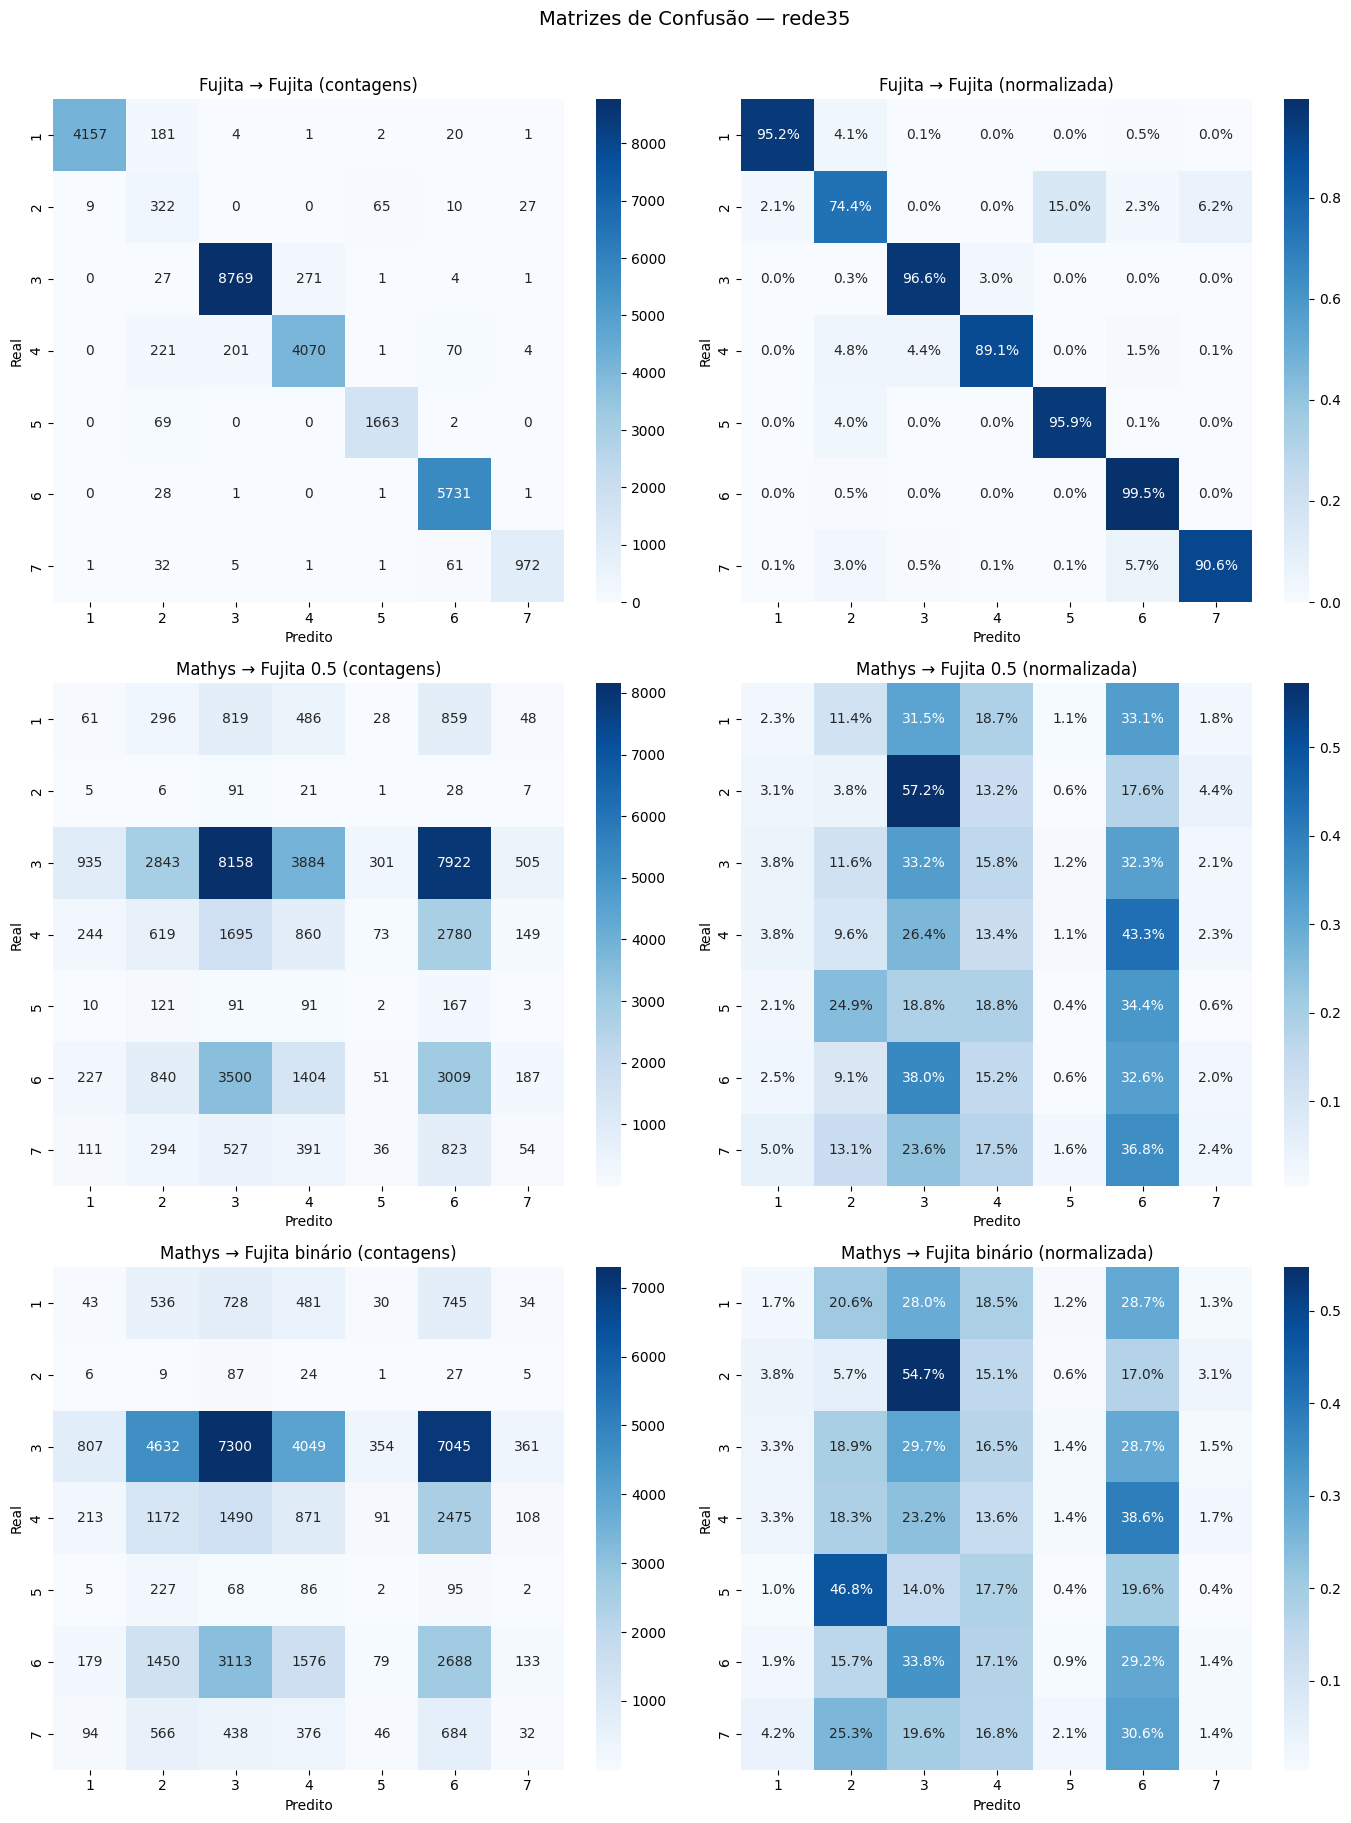

In [25]:
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

avaliador_f.plotar(    titulo='Fujita → Fujita (contagens)',          ax=axes[0, 0])
avaliador_f.plotar(    titulo='Fujita → Fujita (normalizada)',         ax=axes[0, 1], normalizado=True)
avaliador_m.plotar(    titulo='Fujita → Mathys 0.5 (contagens)',       ax=axes[1, 0])
avaliador_m.plotar(    titulo='Fujita → Mathys 0.5 (normalizada)',     ax=axes[1, 1], normalizado=True)
avaliador_m_bin.plotar(titulo='Fujita → Mathys binário (contagens)',   ax=axes[2, 0])
avaliador_m_bin.plotar(titulo='Fujita → Mathys binário (normalizada)', ax=axes[2, 1], normalizado=True)

plt.suptitle('Matrizes de Confusão — rede35', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 16b. t-SNE — estrutura global das células

Visualização não-linear da separação entre tipos celulares em duas dimensões.

**Passo A** — t-SNE de 5.000 células Fujita no espaço SWeeP (primeiros 50 PCs): mostra se os tipos celulares formam ilhas distintas no espaço de baixa dimensionalidade.

**Passo B** — t-SNE conjunto (5.000 células Fujita ● + 5.000 células Mathys ▲ reconstruídas): células do mesmo tipo das duas espécies devem se sobrepor se a reconstrução pela Hopfield Network preservou as identidades celulares.


Rodando t-SNE em 5000 células Fujita (input: primeiros 50 PCs)...
  Concluído.


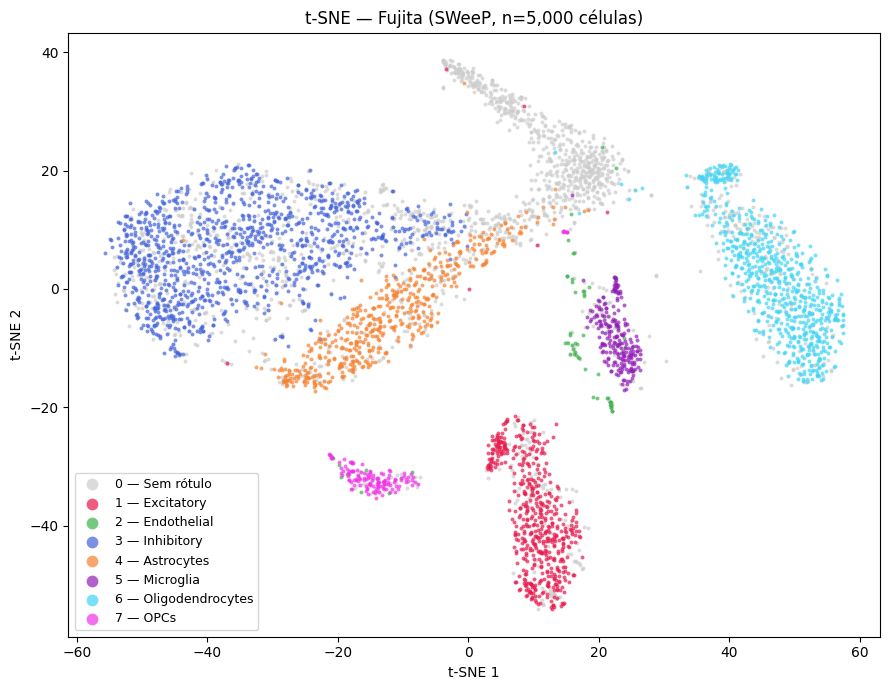

In [26]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA as SkPCA

# Passo A: t-SNE de Fujita no espaço SWeeP
rng_tsne = np.random.default_rng(SEED)
N_TSNE = 5000
idx_f_t = rng_tsne.choice(len(projetor.Wpc), N_TSNE, replace=False)

print(f'Rodando t-SNE em {N_TSNE} células Fujita (input: primeiros 50 PCs)...')
tsne_a = TSNE(n_components=2, perplexity=40, random_state=SEED, n_jobs=-1)
Z_f = tsne_a.fit_transform(projetor.Wpc[idx_f_t, :50])
print('  Concluído.')

fig_tsne_a, ax = plt.subplots(figsize=(9, 7))
for cls in sorted(CORES):
    mask = clo[idx_f_t] == cls
    if mask.any():
        ax.scatter(Z_f[mask, 0], Z_f[mask, 1],
                   c=CORES[cls], label=f'{cls} — {CLASSE_NOMES[cls]}',
                   s=8, alpha=0.7, linewidths=0)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.set_title(f't-SNE — Fujita (SWeeP, n={N_TSNE:,} células)')
ax.legend(markerscale=3, fontsize=9)
plt.tight_layout(); plt.show()

## 16c. DBSCAN — validação de clusters não-supervisionada

Aplica DBSCAN sobre as coordenadas t-SNE 2D do Fujita para verificar se os clusters de densidade concordam com os rótulos biológicos `clo`.


In [27]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score

dbscan = DBSCAN(eps=2.5, min_samples=15)
db_labels = dbscan.fit_predict(Z_f)
ari = adjusted_rand_score(clo[idx_f_t], db_labels)
print(f'DBSCAN ARI (Fujita t-SNE 2D): {ari:.4f}')

DBSCAN ARI (Fujita t-SNE 2D): 0.3553


## 17. Reconstrução dos Genes Ausentes no Mathys

Análise e métricas por gene para os genes ausentes no Mathys que foram recuperados pela rede Hopfield.


In [28]:
# Metrics por gene para os genes ausentes
print(f'Total de células com genes recuperados: {np.sum(recuperados_count > 0)}')

Total de células com genes recuperados: 11186


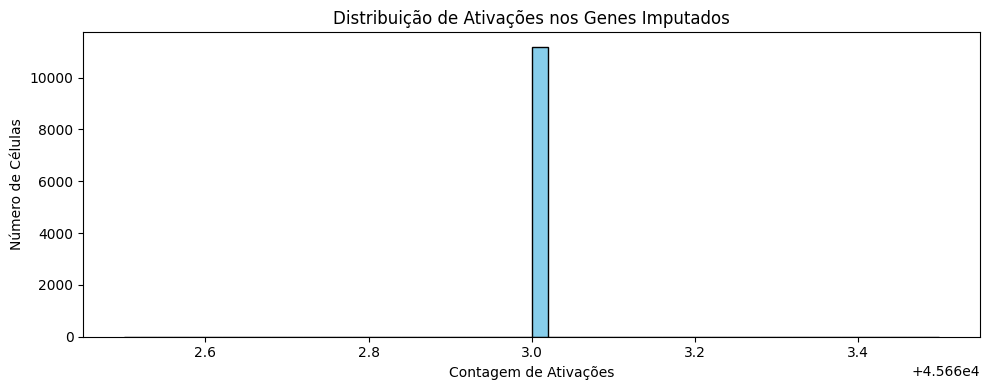

In [29]:
# Visualizações da reconstrução dos genes ausentes
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(recuperados_count, bins=50, color='skyblue', edgecolor='black')
ax.set_title('Distribuição de Ativações nos Genes Imputados')
ax.set_xlabel('Contagem de Ativações')
ax.set_ylabel('Número de Células')
plt.tight_layout(); plt.show()

## 18. Relatório Final do Experimento

Gera o relatório em HTML/Markdown com métricas consolidadas do experimento.


In [31]:
import importlib
import treinamento.gerador_relatorio as _gr_mod
importlib.reload(_gr_mod)
from treinamento.gerador_relatorio import GeradorRelatorio

relatorio = GeradorRelatorio(
    out_dir          = OUT_RELATORIO,
    nome_experimento = 'experimento_dataset_expandido_11k',
)

relatorio.adicionar_metadados(
    titulo           = 'Pipeline Hopfield Dataset Expandido (~11.000 genes)',
    modelo           = 'Modern Hopfield Network (Ramsauer et al., 2020)',
    beta             = rede35.beta,
    n_iters          = rede35.n_iters,
    binary           = rede35.binary,
    threshold        = rede35.threshold,
    n_padroes        = int(rede35.patterns.shape[0]),
    n_genes          = int(perf35.shape[1]),
    n_classes        = 7,
    nc_subclusters   = NC,
    seed             = SEED,
)

relatorio.adicionar_avaliador('Fujita → Fujita',       avaliador_f)
relatorio.adicionar_avaliador('Mathys → Fujita (0.5)', avaliador_m)
relatorio.adicionar_avaliador('Mathys → Fujita (bin)', avaliador_m_bin)

relatorio.gerar()
print(relatorio)
print('Relatório final gerado com sucesso!')

[GeradorRelatorio] Salvo: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\relatorio\metricas_globais.csv
[GeradorRelatorio] Salvo: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\relatorio\metricas_por_classe.csv
[GeradorRelatorio] HTML salvo: c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\relatorio\relatorio_experimento_dataset_expandido_11k.html
[GeradorRelatorio] Concluído.
GeradorRelatorio(
  out_dir          = c:\Users\Leticia\Documents\Letworkspace\pipiline_hopifield\outputs\relatorio
  nome_experimento = experimento_dataset_expandido_11k
  avaliadores      = ['Fujita → Fujita', 'Mathys → Fujita (0.5)', 'Mathys → Fujita (bin)']
)
Relatório final gerado com sucesso!
